# Environment Setup


In [ ]:
import numpy as np # linear algebra
from google.colab import drive
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import Markdown
import kagglehub
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
drive.mount('/content/drive')
import random
import numpy as np
import torch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# For deterministic behavior with cuDNN (may impact performance)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Mounted at /content/drive


#Data Splitting

##Dual stream dataset

In [ ]:
# Define the dual-stream dataset with separate transforms.
class DualStreamDataset(Dataset):
    def __init__(self, org_dir, kmeans_dir, transform_org=None, transform_kmeans=None):
        self.org_dir = org_dir
        self.kmeans_dir = kmeans_dir
        self.transform_org = transform_org
        self.transform_kmeans = transform_kmeans
        self.samples = []

        # Get sorted class names (folder names)
        classes = sorted([d for d in os.listdir(org_dir)
                          if os.path.isdir(os.path.join(org_dir, d))])
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}
        self.classes = classes

        # Loop through each class directory and collect file paths.
        for cls in classes:
            org_class_dir = os.path.join(org_dir, cls)
            kmeans_class_dir = os.path.join(kmeans_dir, cls)
            for fname in os.listdir(org_class_dir):
                if fname.lower().endswith('.jpg'):
                    base_name = os.path.splitext(fname)[0]
                    kmeans_fname = f"{base_name}_final_masked.jpg"
                    org_path = os.path.join(org_class_dir, fname)
                    kmeans_path = os.path.join(kmeans_class_dir, kmeans_fname)
                    if os.path.exists(kmeans_path):
                        label = self.class_to_idx[cls]
                        self.samples.append((org_path, kmeans_path, label))
                    else:
                        print(f"Warning: {kmeans_path} not found.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        org_path, kmeans_path, label = self.samples[index]
        org_image = Image.open(org_path).convert('RGB')
        kmeans_image = Image.open(kmeans_path).convert('RGB')

        # Apply transforms: original image gets augmentation; k-means gets basic transform.
        if self.transform_org:
            org_image = self.transform_org(org_image)
        if self.transform_kmeans:
            kmeans_image = self.transform_kmeans(kmeans_image)

        return org_image, kmeans_image, label

##Original Image Transform

In [ ]:
# Define transform for original images: apply random rotation and color jittering.
org_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Apply color jittering
    T.Resize((224, 224)),  # Resize image to 224x224
    T.ToTensor()  # Convert PIL image to tensor (without normalization)
])

##K-mean image transform

In [ ]:
# Define basic transform for k-means images (only resize and convert to tensor).
kmeans_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

##Create dataset

In [ ]:
# Create the dataset instance.
dataset = DualStreamDataset(
    org_dir="/content/drive/MyDrive/tomato_dataset/color",      # Replace with your original image directory
    kmeans_dir="/content/drive/MyDrive/tomato_dataset/kmean_clustered",  # Replace with your k-means image directory
    transform_org=org_transform,
    transform_kmeans=kmeans_transform
)

# Split dataset into train (70%), validation (15%), and test (15%) sets.
total_samples = len(dataset)
train_size = int(0.7 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Create DataLoaders for each split.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)


In [ ]:
print(dataset.class_to_idx)

{'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}


##Verify result (Optional)

In [ ]:
# Example: iterate through one batch from the training loader and print shapes.
for org_img, kmeans_img, labels in train_loader:
    print("Original image batch shape:", org_img.shape)
    print("K-means image batch shape:", kmeans_img.shape)
    print("Labels:", labels)
    break

Original image batch shape: torch.Size([32, 3, 224, 224])
K-means image batch shape: torch.Size([32, 3, 224, 224])
Labels: tensor([9, 4, 1, 7, 2, 6, 0, 6, 4, 7, 2, 7, 0, 7, 4, 7, 5, 9, 2, 0, 7, 4, 7, 7,
        7, 7, 2, 0, 7, 4, 7, 8])


In [ ]:
print("Label names:", dataset.classes)

Label names: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


## Display data sample

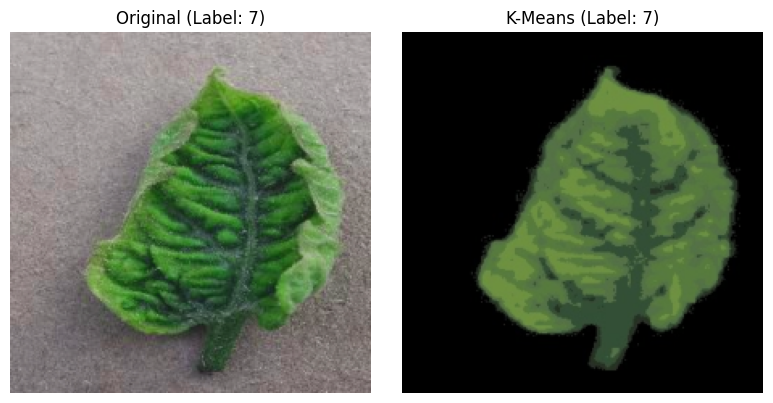

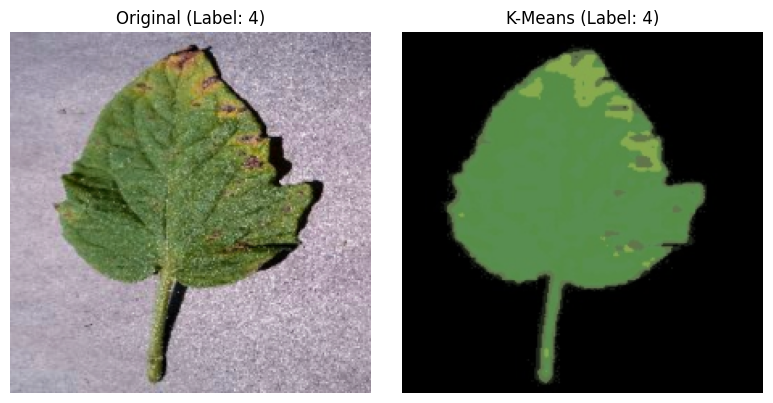

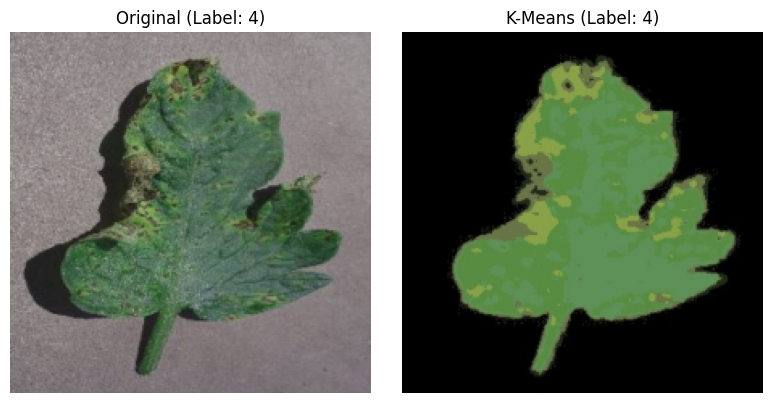

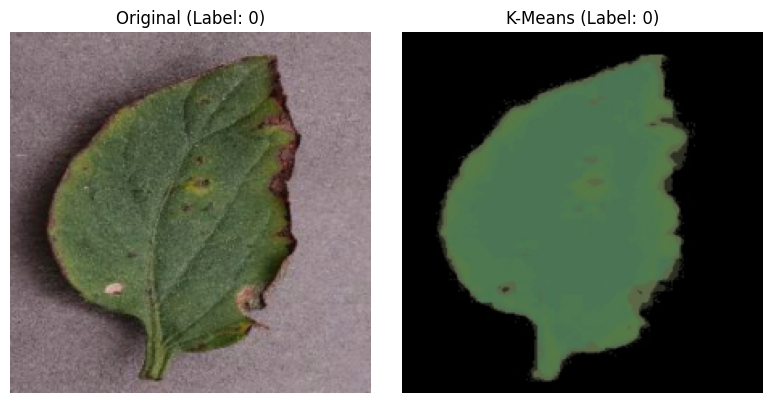

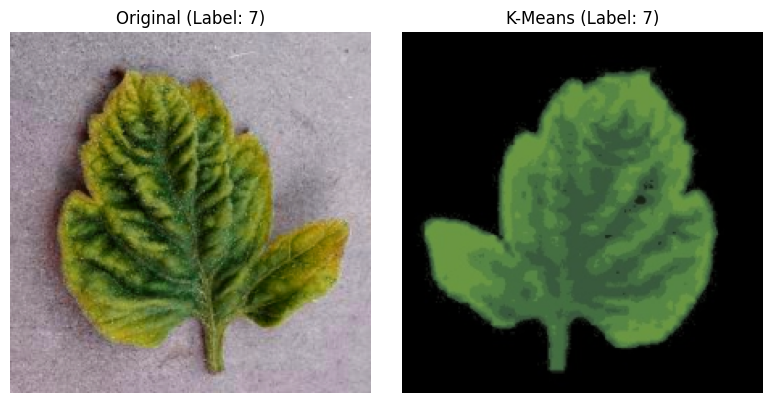

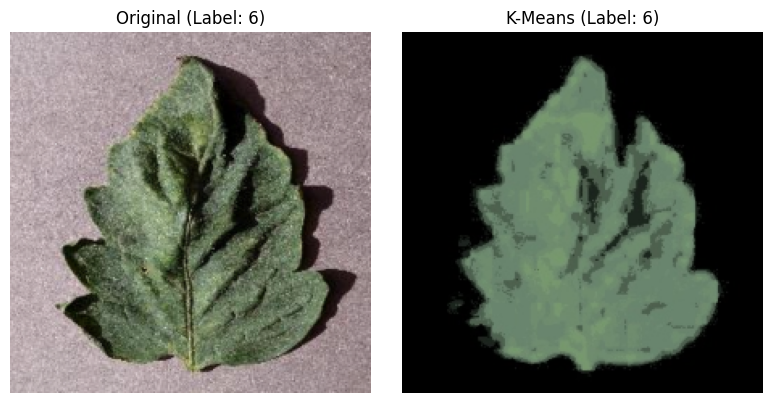

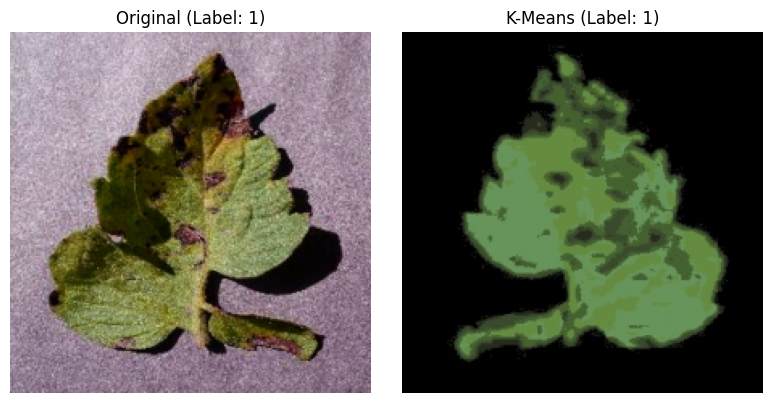

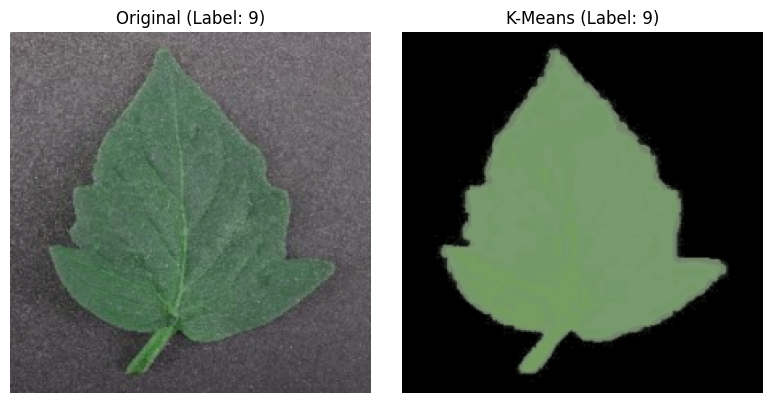

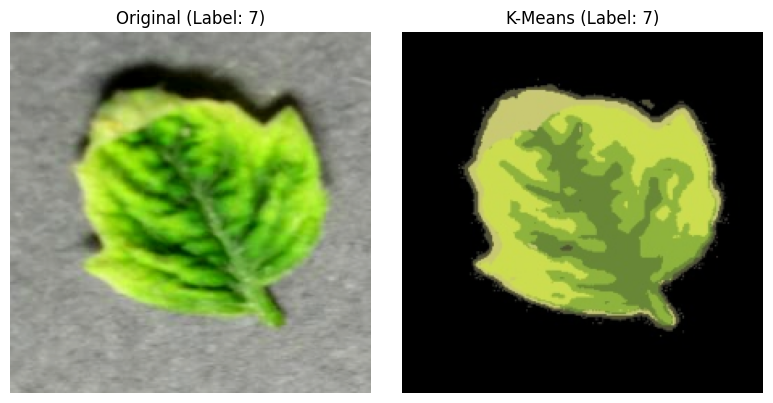

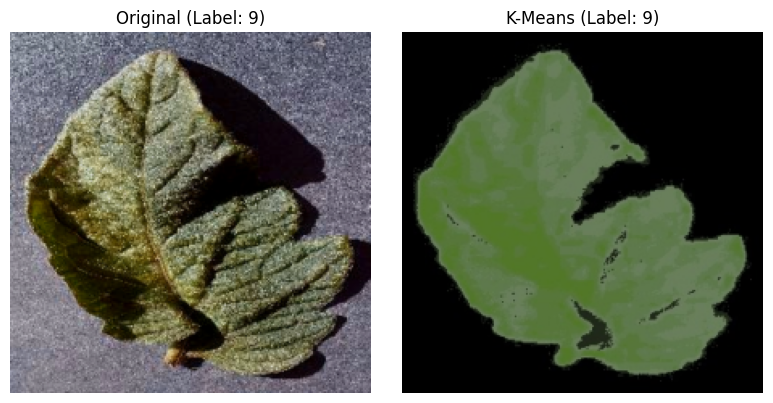

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Suppose you already have a train_loader:
# train_loader = DataLoader(train_dataset, ...)

# Grab one batch of data from the loader.
data_iter = iter(train_loader)
org_batch, kmeans_batch, labels = next(data_iter)

# If you have a list of class names from your dataset, you can use it for a nicer title.
# For example:
# class_names = dataset.classes  # If your dataset has an attribute .classes
class_names = None  # Or replace with the actual class list

# Let's display the first 10 samples in the batch (or fewer if batch_size < 10).
num_to_show = min(10, org_batch.size(0))

def denormalize_and_convert(img_tensor):
    """
    Optional helper to convert a normalized tensor (C,H,W) to a NumPy (H,W,C) for display.
    If you used mean/std normalization, you can unnormalize here.
    """
    # Example for standard ImageNet mean/std:
    # mean = np.array([0.485, 0.456, 0.406])
    # std = np.array([0.229, 0.224, 0.225])
    #
    # img_tensor = img_tensor * torch.tensor(std).view(3,1,1)
    # img_tensor = img_tensor + torch.tensor(mean).view(3,1,1)

    # Convert from (C, H, W) to (H, W, C) and clamp to valid range
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1)
    return img_np

for i in range(num_to_show):
    org_img = denormalize_and_convert(org_batch[i])
    kmeans_img = denormalize_and_convert(kmeans_batch[i])
    label_idx = labels[i].item()

    fig, axs = plt.subplots(1, 2, figsize=(8, 4))

    # Show original image
    axs[0].imshow(org_img)
    if class_names is not None:
        axs[0].set_title(f"Original (Label: {label_idx}, {class_names[label_idx]})")
    else:
        axs[0].set_title(f"Original (Label: {label_idx})")
    axs[0].axis('off')

    # Show k-means image
    axs[1].imshow(kmeans_img)
    if class_names is not None:
        axs[1].set_title(f"K-Means (Label: {label_idx}, {class_names[label_idx]})")
    else:
        axs[1].set_title(f"K-Means (Label: {label_idx})")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
#Check consistency
import os

folder_path = "/content/drive/MyDrive/tomato_dataset/kmean_clustered/Tomato___Bacterial_spot"
# List all entries in the folder
entries = os.listdir(folder_path)
# Filter only files (not directories)
files = [f for f in entries if os.path.isfile(os.path.join(folder_path, f))]
print("Number of files:", len(files))

Number of files: 2127


#Baseline Levit (0.986)

In [ ]:
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader
from tqdm import tqdm  # for progress bars

# Define a small MLP for fusion
class FusionMLP(nn.Module):
    def __init__(self, input_dim=768, hidden_dims=[512, 256], num_classes=10):
        super(FusionMLP, self).__init__()
        layers = []
        in_dim = input_dim
        for hdim in hidden_dims:
            layers.append(nn.Linear(in_dim, hdim))
            layers.append(nn.ReLU())
            # Optional: You could add dropout or batchnorm here
            layers.append(nn.Dropout(p=0.2))
            in_dim = hdim
        # Final layer maps to the number of classes
        layers.append(nn.Linear(in_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)

# Define the dual-stream model that fuses features from two views.
class DualStreamLeViT(nn.Module):
    def __init__(self, num_classes=10):
        super(DualStreamLeViT, self).__init__()
        # Create two LeViT feature extractors using the levit_192 variant.
        # Each stream outputs a 384-dim feature vector.
        self.stream1 = timm.create_model("levit_192", pretrained=True, num_classes=0)
        self.stream2 = timm.create_model("levit_192", pretrained=True, num_classes=0)

        # Instead of a single Linear layer, we use our multi-layer MLP
        # Input dim is 768 because we are concatenating two 384-dim features
        self.fusion_mlp = FusionMLP(input_dim=768, hidden_dims=[512, 256], num_classes=num_classes)

    def forward(self, x1, x2):
        # Extract features from each stream
        feat1 = self.stream1(x1)  # shape: [batch_size, 384]
        feat2 = self.stream2(x2)  # shape: [batch_size, 384]

        # Concatenate features from both streams
        fused = torch.cat((feat1, feat2), dim=1)  # shape: [batch_size, 768]

        # Pass concatenated features through the MLP
        logits = self.fusion_mlp(fused)           # shape: [batch_size, num_classes]
        return logits

In [ ]:
import torch
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# Assuming you have defined your model class somewhere
# from my_model_module import MyModel

# Instantiate the model architecture (make sure it matches the training model)
model = DualStreamLeViT(num_classes=10)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Load the state dictionary from a .pth file
model_path = "/content/drive/MyDrive/tomato_dataset/levit_dual_fair__cmp_state_dict.pth"  # update this path to your .pth file location
model.load_state_dict(torch.load(model_path, map_location=device))
criterion = nn.CrossEntropyLoss()




In [ ]:
import time  # Import time module for monitoring
import torch
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# Set the model to evaluation mode.
model.eval()

running_test_loss = 0.0
correct_test = 0
total_test = 0

# Lists to accumulate predictions and true labels for additional metrics.
all_preds = []
all_labels = []

# Create a progress bar for the test loop.
test_bar = tqdm(test_loader, desc="Test", leave=True)

# Start the timer before running the test loop.
start_time = time.time()

with torch.no_grad():
    for orig_images, kmeans_images, labels in test_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass.
        logits = model(orig_images, kmeans_images)
        loss_test = criterion(logits, labels)

        # Accumulate loss and count correct predictions.
        running_test_loss += loss_test.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

        # Save predictions and labels for additional metrics.
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Update the progress bar with the current loss.
        test_bar.set_postfix(loss=loss_test.item())

# Stop the timer after finishing the test loop.
end_time = time.time()
elapsed_time = end_time - start_time

# Compute overall test loss and accuracy.
test_loss = running_test_loss / total_test
test_acc = correct_test / total_test

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.3f}")
print(f"Elapsed Time for Testing: {elapsed_time:.2f} seconds")

# Generate additional performance metrics.
#print("\nClassification Report:")
#print(classification_report(all_labels, all_preds, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


Test: 100%|██████████| 43/43 [00:15<00:00,  2.77it/s, loss=0.453]

Test Loss: 0.4842, Test Accuracy: 0.988
Elapsed Time for Testing: 15.53 seconds
Confusion Matrix:
[[304   1   0   0   0   0   0   1   0   0]
 [  0 148   3   0   1   1   1   0   0   0]
 [  0   0 275   0   0   5   0   0   0   0]
 [  0   0   0 143   1   2   1   1   1   0]
 [  0   1   0   0 263   2   2   1   0   0]
 [  0   0   0   0   1 250   1   0   0   0]
 [  0   0   0   0   1   2 202   0   0   0]
 [  2   0   0   0   0   1   0 801   0   0]
 [  0   0   0   0   0   0   0   0  63   0]
 [  0   0   0   0   0   0   0   0   0 243]]


#Parallel with EfficeintNet-B2 (0.967)

In [ ]:
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader
from tqdm import tqdm  # for progress bars

# Define a small MLP for fusion
class FusionMLP(nn.Module):
    def __init__(self, input_dim=2560, hidden_dims=[512, 256], num_classes=10):
        super(FusionMLP, self).__init__()
        layers = []
        in_dim = input_dim
        for hdim in hidden_dims:
            layers.append(nn.Linear(in_dim, hdim))
            layers.append(nn.ReLU())
            # Optional: add dropout or batchnorm here if desired
            layers.append(nn.Dropout(p=0.2))
            in_dim = hdim
        # Final layer maps to the number of classes
        layers.append(nn.Linear(in_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)

# Define the dual-stream model that fuses features from two views.
class DualStreamEfficientNet(nn.Module):
    def __init__(self, num_classes=10):
        super(DualStreamEfficientNet, self).__init__()
        # Create two EfficientNet-B0 feature extractors.
        # Each stream outputs a 1280-dim feature vector.
        self.stream1 = timm.create_model("efficientnet_b2", pretrained=True, num_classes=0)
        self.stream2 = timm.create_model("efficientnet_b2", pretrained=True, num_classes=0)

        # The Fusion MLP accepts concatenated features (1280 + 1280 = 2560)
        self.fusion_mlp = FusionMLP(input_dim=2560, hidden_dims=[512, 256], num_classes=num_classes)

    def forward(self, x1, x2):
        # Extract features from each stream
        feat1 = self.stream1(x1)  # Expected shape: [batch_size, 1280]
        feat2 = self.stream2(x2)  # Expected shape: [batch_size, 1280]

        # Concatenate features from both streams
        fused = torch.cat((feat1, feat2), dim=1)  # Shape: [batch_size, 2560]

        # Pass concatenated features through the MLP
        logits = self.fusion_mlp(fused)           # Shape: [batch_size, num_classes]
        return logits

# ---------------------------------------------
# Rest of your training script
# ---------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DualStreamEfficientNet(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 40

# Early stopping variables
best_val_loss = float('inf')
best_val_acu = float('inf')
patience = 10
trigger_times = 0
best_model_state = None  # Optional: save the best model state

for epoch in range(num_epochs):
    # ---------------------------
    #  TRAINING
    # ---------------------------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]", leave=False)
    for orig_images, kmeans_images, labels in train_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(orig_images, kmeans_images)
        loss = criterion(logits, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training statistics
        running_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        train_bar.set_postfix(loss=loss.item())

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    # ---------------------------
    #  VALIDATION
    # ---------------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [VAL]", leave=True)
    with torch.no_grad():
        for orig_images, kmeans_images, labels in val_bar:
            orig_images = orig_images.to(device)
            kmeans_images = kmeans_images.to(device)
            labels = labels.to(device)

            logits = model(orig_images, kmeans_images)
            loss_val = criterion(logits, labels)

            running_val_loss += loss_val.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            val_bar.set_postfix(loss=loss_val.item())

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.3f}")

    # ---------------------------
    #  EARLY STOPPING CHECK
    # ---------------------------
    if val_loss < best_val_loss or val_acc > best_val_acu:
        best_val_loss = val_loss
        best_val_acu = val_acc
        trigger_times = 0
        best_model_state = model.state_dict()  # Optionally, save the best model state.
        print("Validation loss improved; saving model.")
    else:
        trigger_times += 1
        print(f"Early stopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered. Stopping training.")
            break

# Optionally, load the best model state after training:
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model state based on validation loss.")



Using device: cuda


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch 1/40 [VAL]: 100%|██████████| 86/86 [00:15<00:00,  5.61it/s, loss=0.0388]


Epoch [1/40] Train Loss: 0.4270, Train Acc: 0.870 | Val Loss: 0.1633, Val Acc: 0.947
Validation loss improved; saving model.


Epoch 2/40 [VAL]: 100%|██████████| 86/86 [00:15<00:00,  5.66it/s, loss=0.0195]


...

Epoch [38/40] Train Loss: 0.0386, Train Acc: 0.990 | Val Loss: 0.0581, Val Acc: 0.979
Early stopping counter: 2 out of 10


Epoch 39/40 [VAL]: 100%|██████████| 86/86 [00:15<00:00,  5.60it/s, loss=7.95e-8]


Epoch [39/40] Train Loss: 0.0557, Train Acc: 0.984 | Val Loss: 0.0606, Val Acc: 0.983
Early stopping counter: 3 out of 10


Epoch 40/40 [VAL]: 100%|██████████| 86/86 [00:15<00:00,  5.56it/s, loss=2.54e-6]

Epoch [40/40] Train Loss: 0.0361, Train Acc: 0.990 | Val Loss: 0.0969, Val Acc: 0.982
Early stopping counter: 4 out of 10
Loaded best model state based on validation loss.


##Test Accuracy

In [ ]:
import torch
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# Set the model to evaluation mode.
model.eval()

running_test_loss = 0.0
correct_test = 0
total_test = 0

# Lists to accumulate predictions and true labels for additional metrics.
all_preds = []
all_labels = []

# Create a progress bar for the test loop.
test_bar = tqdm(test_loader, desc="Test", leave=True)

with torch.no_grad():
    for orig_images, kmeans_images, labels in test_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass.
        logits = model(orig_images, kmeans_images)
        loss_test = criterion(logits, labels)

        # Accumulate loss and count correct predictions.
        running_test_loss += loss_test.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

        # Save predictions and labels for additional metrics.
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Update the progress bar with the current loss.
        test_bar.set_postfix(loss=loss_test.item())

# Compute overall test loss and accuracy.
test_loss = running_test_loss / total_test
test_acc = correct_test / total_test

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.3f}")

# # Generate additional performance metrics.
# print("\nClassification Report:")
# print(classification_report(all_labels, all_preds, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


#Parallel with MobileNetV2_100 (0.978)


In [ ]:
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader
from tqdm import tqdm  # for progress bars

# Define a small MLP for fusion
class FusionMLP(nn.Module):
    def __init__(self, input_dim=2560, hidden_dims=[512, 256], num_classes=10):
        super(FusionMLP, self).__init__()
        layers = []
        in_dim = input_dim
        for hdim in hidden_dims:
            layers.append(nn.Linear(in_dim, hdim))
            layers.append(nn.ReLU())
            # Optional: add dropout or batchnorm here if desired
            layers.append(nn.Dropout(p=0.2))
            in_dim = hdim
        # Final layer maps to the number of classes
        layers.append(nn.Linear(in_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)

# Define the dual-stream model that fuses features from two views.
class DualStreamMobileNet(nn.Module):
    def __init__(self, num_classes=10):
        super(DualStreamMobileNet, self).__init__()
        # Create two MobileNetV2 feature extractors.
        # Each stream outputs a 1280-dim feature vector.
        self.stream1 = timm.create_model("mobilenetv2_100", pretrained=True, num_classes=0)
        self.stream2 = timm.create_model("mobilenetv2_100", pretrained=True, num_classes=0)

        # The Fusion MLP accepts concatenated features (1280 + 1280 = 2560)
        self.fusion_mlp = FusionMLP(input_dim=2560, hidden_dims=[512, 256], num_classes=num_classes)

    def forward(self, x1, x2):
        # Extract features from each stream
        feat1 = self.stream1(x1)  # Expected shape: [batch_size, 1280]
        feat2 = self.stream2(x2)  # Expected shape: [batch_size, 1280]

        # Concatenate features from both streams
        fused = torch.cat((feat1, feat2), dim=1)  # Shape: [batch_size, 2560]

        # Pass concatenated features through the MLP
        logits = self.fusion_mlp(fused)           # Shape: [batch_size, num_classes]
        return logits

# ---------------------------------------------
# Rest of your training script
# ---------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DualStreamMobileNet(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 40

# Early stopping variables
best_val_loss = float('inf')
best_val_acu = float('inf')
patience = 10
trigger_times = 0
best_model_state = None  # Optionally, save the best model state

for epoch in range(num_epochs):
    # ---------------------------
    #  TRAINING
    # ---------------------------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]", leave=False)
    for orig_images, kmeans_images, labels in train_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(orig_images, kmeans_images)
        loss = criterion(logits, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training statistics
        running_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        train_bar.set_postfix(loss=loss.item())

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    # ---------------------------
    #  VALIDATION
    # ---------------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [VAL]", leave=True)
    with torch.no_grad():
        for orig_images, kmeans_images, labels in val_bar:
            orig_images = orig_images.to(device)
            kmeans_images = kmeans_images.to(device)
            labels = labels.to(device)

            logits = model(orig_images, kmeans_images)
            loss_val = criterion(logits, labels)

            running_val_loss += loss_val.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            val_bar.set_postfix(loss=loss_val.item())

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.3f}")

    # ---------------------------
    #  EARLY STOPPING CHECK
    # ---------------------------
    if val_loss < best_val_loss or val_acc > best_val_acu:
        best_val_loss = val_loss
        best_val_acu = val_acc
        trigger_times = 0
        best_model_state = model.state_dict()  # Optionally, save the best model state.
        print("Validation loss improved; saving model.")
    else:
        trigger_times += 1
        print(f"Early stopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered. Stopping training.")
            break

# Optionally, load the best model state after training:
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model state based on validation loss.")


In [ ]:
import torch
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# Set the model to evaluation mode.
model.eval()

running_test_loss = 0.0
correct_test = 0
total_test = 0

# Lists to accumulate predictions and true labels for additional metrics.
all_preds = []
all_labels = []

# Create a progress bar for the test loop.
test_bar = tqdm(test_loader, desc="Test", leave=True)

with torch.no_grad():
    for orig_images, kmeans_images, labels in test_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass.
        logits = model(orig_images, kmeans_images)
        loss_test = criterion(logits, labels)

        # Accumulate loss and count correct predictions.
        running_test_loss += loss_test.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

        # Save predictions and labels for additional metrics.
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Update the progress bar with the current loss.
        test_bar.set_postfix(loss=loss_test.item())

# Compute overall test loss and accuracy.
test_loss = running_test_loss / total_test
test_acc = correct_test / total_test

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.3f}")

# # Generate additional performance metrics.
# print("\nClassification Report:")
# print(classification_report(all_labels, all_preds, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


Test: 100%|██████████| 86/86 [00:15<00:00,  5.49it/s, loss=9.2e-6]

Test Loss: 0.0737, Test Accuracy: 0.978
Confusion Matrix:
[[303   0   2   0   0   0   1   0   0   0]
 [  0 137   8   2   6   0   1   0   0   0]
 [  0   1 278   1   0   0   0   0   0   0]
 [  0   0   0 149   0   0   0   0   0   0]
 [  0   1   2   7 255   0   2   0   2   0]
 [  0   0   0   0   0 249   2   0   0   1]
 [  0   1   0   1   2   1 197   0   0   3]
 [  4   0   1   0   0   4   0 793   2   0]
 [  0   0   0   1   0   0   0   0  62   0]
 [  0   0   0   0   0   0   0   0   0 243]]


#Parallel with DenseNet121 (0.981)

In [ ]:
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader
from tqdm import tqdm  # for progress bars

# Define a small MLP for fusion
class FusionMLP(nn.Module):
    def __init__(self, input_dim=2048, hidden_dims=[512, 256], num_classes=10):
        super(FusionMLP, self).__init__()
        layers = []
        in_dim = input_dim
        for hdim in hidden_dims:
            layers.append(nn.Linear(in_dim, hdim))
            layers.append(nn.ReLU())
            # Optional: add dropout or batchnorm here if desired
            layers.append(nn.Dropout(p=0.2))
            in_dim = hdim
        # Final layer maps to the number of classes
        layers.append(nn.Linear(in_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)

# Define the dual-stream model that fuses features from two views.
class DualStreamDenseNet(nn.Module):
    def __init__(self, num_classes=10):
        super(DualStreamDenseNet, self).__init__()
        # Create two DenseNet-121 feature extractors.
        # Each stream outputs a 1024-dim feature vector.
        self.stream1 = timm.create_model("densenet121", pretrained=True, num_classes=0)
        self.stream2 = timm.create_model("densenet121", pretrained=True, num_classes=0)

        # The Fusion MLP accepts concatenated features (1024 + 1024 = 2048)
        self.fusion_mlp = FusionMLP(input_dim=2048, hidden_dims=[512, 256], num_classes=num_classes)

    def forward(self, x1, x2):
        # Extract features from each stream
        feat1 = self.stream1(x1)  # Expected shape: [batch_size, 1024]
        feat2 = self.stream2(x2)  # Expected shape: [batch_size, 1024]

        # Concatenate features from both streams
        fused = torch.cat((feat1, feat2), dim=1)  # Shape: [batch_size, 2048]

        # Pass concatenated features through the MLP
        logits = self.fusion_mlp(fused)           # Shape: [batch_size, num_classes]
        return logits

# ---------------------------------------------
# Rest of your training script
# ---------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DualStreamDenseNet(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 40

# Early stopping variables
best_val_loss = float('inf')
best_val_acu = float('inf')
patience = 10
trigger_times = 0
best_model_state = None  # Optionally, save the best model state

for epoch in range(num_epochs):
    # ---------------------------
    #  TRAINING
    # ---------------------------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]", leave=False)
    for orig_images, kmeans_images, labels in train_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(orig_images, kmeans_images)
        loss = criterion(logits, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training statistics
        running_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        train_bar.set_postfix(loss=loss.item())

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    # ---------------------------
    #  VALIDATION
    # ---------------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [VAL]", leave=True)
    with torch.no_grad():
        for orig_images, kmeans_images, labels in val_bar:
            orig_images = orig_images.to(device)
            kmeans_images = kmeans_images.to(device)
            labels = labels.to(device)

            logits = model(orig_images, kmeans_images)
            loss_val = criterion(logits, labels)

            running_val_loss += loss_val.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            val_bar.set_postfix(loss=loss_val.item())

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.3f}")

    # ---------------------------
    #  EARLY STOPPING CHECK
    # ---------------------------
    if val_loss < best_val_loss or val_acc > best_val_acu:
        best_val_loss = val_loss
        best_val_acu = val_acc
        trigger_times = 0
        best_model_state = model.state_dict()  # Optionally, save the best model state.
        print("Validation loss improved; saving model.")
    else:
        trigger_times += 1
        print(f"Early stopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered. Stopping training.")
            break

# Optionally, load the best model state after training:
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model state based on validation loss.")


In [ ]:
import torch
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# Set the model to evaluation mode.
model.eval()

running_test_loss = 0.0
correct_test = 0
total_test = 0

# Lists to accumulate predictions and true labels for additional metrics.
all_preds = []
all_labels = []

# Create a progress bar for the test loop.
test_bar = tqdm(test_loader, desc="Test", leave=True)

with torch.no_grad():
    for orig_images, kmeans_images, labels in test_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass.
        logits = model(orig_images, kmeans_images)
        loss_test = criterion(logits, labels)

        # Accumulate loss and count correct predictions.
        running_test_loss += loss_test.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

        # Save predictions and labels for additional metrics.
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Update the progress bar with the current loss.
        test_bar.set_postfix(loss=loss_test.item())

# Compute overall test loss and accuracy.
test_loss = running_test_loss / total_test
test_acc = correct_test / total_test

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.3f}")

# # Generate additional performance metrics.
# print("\nClassification Report:")
# print(classification_report(all_labels, all_preds, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


Test: 100%|██████████| 86/86 [00:15<00:00,  5.44it/s, loss=0]


Test Loss: 0.0788, Test Accuracy: 0.981
Confusion Matrix:
[[305   0   1   0   0   0   0   0   0   0]
 [  1 149   2   0   2   0   0   0   0   0]
 [  0   1 277   0   0   0   1   0   0   1]
 [  0   0   0 140   5   3   0   0   0   1]
 [  2   0   0   1 261   0   2   0   2   1]
 [  0   0   0   0   0 252   0   0   0   0]
 [  2   1   0   0   1  13 187   1   0   0]
 [  2   0   1   1   0   3   0 797   0   0]
 [  0   0   0   1   0   0   0   0  62   0]
 [  0   0   0   0   0   0   0   0   0 243]]


#Parallel with VGG16 (0.836)

In [ ]:
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader
from tqdm import tqdm  # for progress bars

# Define a small MLP for fusion
# Change input_dim to 8192
class FusionMLP(nn.Module):
    def __init__(self, input_dim=8192, hidden_dims=[512, 256], num_classes=10):
        super(FusionMLP, self).__init__()
        layers = []
        in_dim = input_dim
        for hdim in hidden_dims:
            layers.append(nn.Linear(in_dim, hdim))
            layers.append(nn.ReLU())
            # Optional: add dropout or batchnorm here if desired
            layers.append(nn.Dropout(p=0.2))
            in_dim = hdim
        # Final layer maps to the number of classes
        layers.append(nn.Linear(in_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)

# Define the dual-stream model that fuses features from two views using VGG16.
class DualStreamVGG16(nn.Module):
    def __init__(self, num_classes=10):
        super(DualStreamVGG16, self).__init__()
        # Create two VGG16 feature extractors.
        # Each stream outputs a 512-dim feature vector after global pooling.
        self.stream1 = timm.create_model("vgg16", pretrained=True, num_classes=0)
        self.stream2 = timm.create_model("vgg16", pretrained=True, num_classes=0)

        # The Fusion MLP accepts concatenated features (512 + 512 = 1024)
        self.fusion_mlp = FusionMLP(input_dim=8192, hidden_dims=[512, 256], num_classes=num_classes)

    def forward(self, x1, x2):
        # Extract features from each stream
        feat1 = self.stream1(x1)  # Expected shape: [batch_size, 512]
        feat2 = self.stream2(x2)  # Expected shape: [batch_size, 512]

        # Concatenate features from both streams
        fused = torch.cat((feat1, feat2), dim=1)  # Shape: [batch_size, 1024]

        # Pass concatenated features through the MLP
        logits = self.fusion_mlp(fused)           # Shape: [batch_size, num_classes]
        return logits

# ---------------------------------------------
# Rest of your training script
# ---------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DualStreamVGG16(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 40

# Early stopping variables
best_val_loss = float('inf')
best_val_acu = float('inf')
patience = 10
trigger_times = 0
best_model_state = None  # Optionally, save the best model state

for epoch in range(num_epochs):
    # ---------------------------
    #  TRAINING
    # ---------------------------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]", leave=False)
    for orig_images, kmeans_images, labels in train_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(orig_images, kmeans_images)
        loss = criterion(logits, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training statistics
        running_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        train_bar.set_postfix(loss=loss.item())

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    # ---------------------------
    #  VALIDATION
    # ---------------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [VAL]", leave=True)
    with torch.no_grad():
        for orig_images, kmeans_images, labels in val_bar:
            orig_images = orig_images.to(device)
            kmeans_images = kmeans_images.to(device)
            labels = labels.to(device)

            logits = model(orig_images, kmeans_images)
            loss_val = criterion(logits, labels)

            running_val_loss += loss_val.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            val_bar.set_postfix(loss=loss_val.item())

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.3f}")

    # ---------------------------
    #  EARLY STOPPING CHECK
    # ---------------------------
    if val_loss < best_val_loss or val_acc > best_val_acu:
        best_val_loss = val_loss
        best_val_acu = val_acc
        trigger_times = 0
        best_model_state = model.state_dict()  # Optionally, save the best model state.
        print("Validation loss improved; saving model.")
    else:
        trigger_times += 1
        print(f"Early stopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered. Stopping training.")
            break

# Optionally, load the best model state after training:
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model state based on validation loss.")

Using device: cuda


Epoch 1/40 [VAL]: 100%|██████████| 86/86 [00:15<00:00,  5.56it/s, loss=1.13]


Epoch [1/40] Train Loss: 1.8713, Train Acc: 0.353 | Val Loss: 1.4108, Val Acc: 0.513
Validation loss improved; saving model.


Epoch 2/40 [VAL]: 100%|██████████| 86/86 [00:15<00:00,  5.60it/s, loss=0.634]


Epoch [2/40] Train Loss: 1.2930, Train Acc: 0.547 | Val Loss: 1.0286, Val Acc: 0.655
Validation loss improved; saving model.


...

Epoch [38/40] Train Loss: 0.1235, Train Acc: 0.966 | Val Loss: 0.9737, Val Acc: 0.825
Early stopping counter: 2 out of 10


Epoch 39/40 [VAL]: 100%|██████████| 86/86 [00:15<00:00,  5.41it/s, loss=0.00618]


Epoch [39/40] Train Loss: 0.1447, Train Acc: 0.960 | Val Loss: 0.9299, Val Acc: 0.812
Early stopping counter: 3 out of 10


Epoch 40/40 [VAL]: 100%|██████████| 86/86 [00:15<00:00,  5.51it/s, loss=0.00291]

Epoch [40/40] Train Loss: 0.0886, Train Acc: 0.974 | Val Loss: 0.8171, Val Acc: 0.823
Early stopping counter: 4 out of 10
Loaded best model state based on validation loss.


In [ ]:
import torch
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# Set the model to evaluation mode.
model.eval()

running_test_loss = 0.0
correct_test = 0
total_test = 0

# Lists to accumulate predictions and true labels for additional metrics.
all_preds = []
all_labels = []

# Create a progress bar for the test loop.
test_bar = tqdm(test_loader, desc="Test", leave=True)

with torch.no_grad():
    for orig_images, kmeans_images, labels in test_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass.
        logits = model(orig_images, kmeans_images)
        loss_test = criterion(logits, labels)

        # Accumulate loss and count correct predictions.
        running_test_loss += loss_test.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

        # Save predictions and labels for additional metrics.
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Update the progress bar with the current loss.
        test_bar.set_postfix(loss=loss_test.item())

# Compute overall test loss and accuracy.
test_loss = running_test_loss / total_test
test_acc = correct_test / total_test

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.3f}")

# # Generate additional performance metrics.
# print("\nClassification Report:")
# print(classification_report(all_labels, all_preds, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Test: 100%|██████████| 86/86 [00:18<00:00,  4.77it/s, loss=1.25]

Test Loss: 0.7657, Test Accuracy: 0.836
Confusion Matrix:
[[274  14   7   0  14   2   0   0   0   1]
 [ 16  75  20   2  17   7   6   0   0   0]
 [  9  19 248   3  11   3   1   1   0   1]
 [  2  11   4  85  17   7   0   2   0   0]
 [ 12  12  19  16 183   4   4   8   5   1]
 [  3   3   1   3   2 223  13   2   0   2]
 [ 18  17   1   0   7  17 140   1   0  12]
 [  1   3   2   4   5  13   1 777   2   0]
 [  0   0   0   3   3   0   0   3  43   0]
 [  1   3   0   0   3   6  14   0   0 230]]


#Parallel with VGG19 (0.966)

In [ ]:
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader
from tqdm import tqdm  # for progress bars

# Define a small MLP for fusion
class FusionMLP(nn.Module):
    def __init__(self, input_dim=8192, hidden_dims=[512, 256], num_classes=10):
        super(FusionMLP, self).__init__()
        layers = []
        in_dim = input_dim
        for hdim in hidden_dims:
            layers.append(nn.Linear(in_dim, hdim))
            layers.append(nn.ReLU())
            # Optional: add dropout or batchnorm here if desired
            layers.append(nn.Dropout(p=0.2))
            in_dim = hdim
        # Final layer maps to the number of classes
        layers.append(nn.Linear(in_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)

# Define the dual-stream model that fuses features from two views using VGG19.
class DualStreamVGG19(nn.Module):
    def __init__(self, num_classes=10):
        super(DualStreamVGG19, self).__init__()
        # Create two VGG19 feature extractors.
        # Each stream outputs a 512-dim feature vector after global pooling.
        self.stream1 = timm.create_model("vgg19", pretrained=True, num_classes=0)
        self.stream2 = timm.create_model("vgg19", pretrained=True, num_classes=0)

        # The Fusion MLP accepts concatenated features (512 + 512 = 1024)
        self.fusion_mlp = FusionMLP(input_dim=8192, hidden_dims=[512, 256], num_classes=num_classes)

    def forward(self, x1, x2):
        # Extract features from each stream
        feat1 = self.stream1(x1)  # Expected shape: [batch_size, 512]
        feat2 = self.stream2(x2)  # Expected shape: [batch_size, 512]

        # Concatenate features from both streams
        fused = torch.cat((feat1, feat2), dim=1)  # Shape: [batch_size, 1024]

        # Pass concatenated features through the MLP
        logits = self.fusion_mlp(fused)           # Shape: [batch_size, num_classes]
        return logits

# ---------------------------------------------
# Rest of your training script
# ---------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DualStreamVGG19(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 40

# Early stopping variables
best_val_loss = float('inf')
best_val_acu = float('inf')
patience = 10
trigger_times = 0
best_model_state = None  # Optionally, save the best model state

for epoch in range(num_epochs):
    # ---------------------------
    #  TRAINING
    # ---------------------------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]", leave=False)
    for orig_images, kmeans_images, labels in train_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(orig_images, kmeans_images)
        loss = criterion(logits, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training statistics
        running_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        train_bar.set_postfix(loss=loss.item())

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    # ---------------------------
    #  VALIDATION
    # ---------------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [VAL]", leave=True)
    with torch.no_grad():
        for orig_images, kmeans_images, labels in val_bar:
            orig_images = orig_images.to(device)
            kmeans_images = kmeans_images.to(device)
            labels = labels.to(device)

            logits = model(orig_images, kmeans_images)
            loss_val = criterion(logits, labels)

            running_val_loss += loss_val.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            val_bar.set_postfix(loss=loss_val.item())

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.3f}")

    # ---------------------------
    #  EARLY STOPPING CHECK
    # ---------------------------
    if val_loss < best_val_loss or val_acc > best_val_acu:
        best_val_loss = val_loss
        best_val_acu = val_acc
        trigger_times = 0
        best_model_state = model.state_dict()  # Optionally, save the best model state.
        print("Validation loss improved; saving model.")
    else:
        trigger_times += 1
        print(f"Early stopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered. Stopping training.")
            break

# Optionally, load the best model state after training:
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model state based on validation loss.")

In [ ]:
import torch
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# Set the model to evaluation mode.
model.eval()

running_test_loss = 0.0
correct_test = 0
total_test = 0

# Lists to accumulate predictions and true labels for additional metrics.
all_preds = []
all_labels = []

# Create a progress bar for the test loop.
test_bar = tqdm(test_loader, desc="Test", leave=True)

with torch.no_grad():
    for orig_images, kmeans_images, labels in test_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass.
        logits = model(orig_images, kmeans_images)
        loss_test = criterion(logits, labels)

        # Accumulate loss and count correct predictions.
        running_test_loss += loss_test.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

        # Save predictions and labels for additional metrics.
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Update the progress bar with the current loss.
        test_bar.set_postfix(loss=loss_test.item())

# Compute overall test loss and accuracy.
test_loss = running_test_loss / total_test
test_acc = correct_test / total_test

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.3f}")

# # Generate additional performance metrics.
# print("\nClassification Report:")
# print(classification_report(all_labels, all_preds, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

#Parallel with AlexNet (0.865)

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader
from tqdm import tqdm  # for progress bars

def alexnet_feature_extractor():
    """
    Returns a feature extractor based on AlexNet.
    This extractor runs the input through AlexNet's feature layers,
    then the avgpool, flattens the output, and finally applies the first
    linear layer from the classifier (which maps to 4096 dimensions).
    """
    alexnet = models.alexnet(pretrained=True)
    # Create a sequential model that extracts features up to the first fc layer.
    extractor = nn.Sequential(
        alexnet.features,           # Convolutional layers.
        alexnet.avgpool,            # Adaptive average pooling.
        nn.Flatten(),               # Flatten the output.
        alexnet.classifier[1],      # The first Linear layer: Linear(256*6*6, 4096).
        nn.ReLU(inplace=True)       # Activation.
    )
    return extractor

# Define a small MLP for fusion.
class FusionMLP(nn.Module):
    def __init__(self, input_dim=8192, hidden_dims=[512, 256], num_classes=10):
        super(FusionMLP, self).__init__()
        layers = []
        in_dim = input_dim
        for hdim in hidden_dims:
            layers.append(nn.Linear(in_dim, hdim))
            layers.append(nn.ReLU())
            # Optional: add dropout or batchnorm here if desired.
            layers.append(nn.Dropout(p=0.2))
            in_dim = hdim
        # Final layer maps to the number of classes.
        layers.append(nn.Linear(in_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)

# Define the dual-stream model that fuses features from two views using AlexNet.
class DualStreamAlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(DualStreamAlexNet, self).__init__()
        # Create two AlexNet feature extractors using torchvision.
        # Each stream outputs a 4096-dim feature vector.
        self.stream1 = alexnet_feature_extractor()
        self.stream2 = alexnet_feature_extractor()

        # The Fusion MLP accepts concatenated features (4096 + 4096 = 8192).
        self.fusion_mlp = FusionMLP(input_dim=8192, hidden_dims=[512, 256], num_classes=num_classes)

    def forward(self, x1, x2):
        # Extract features from each stream.
        feat1 = self.stream1(x1)  # Expected shape: [batch_size, 4096]
        feat2 = self.stream2(x2)  # Expected shape: [batch_size, 4096]

        # Concatenate features from both streams.
        fused = torch.cat((feat1, feat2), dim=1)  # Shape: [batch_size, 8192]

        # Pass concatenated features through the MLP.
        logits = self.fusion_mlp(fused)           # Shape: [batch_size, num_classes]
        return logits

# ---------------------------------------------
# Rest of your training script.
# ---------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DualStreamAlexNet(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 40

# Early stopping variables.
best_val_loss = float('inf')
best_val_acu = 0.0  # Initialize accuracy to 0.0.
patience = 10
trigger_times = 0
best_model_state = None  # Optionally, save the best model state.

for epoch in range(num_epochs):
    # ---------------------------
    #  TRAINING
    # ---------------------------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]", leave=False)
    for orig_images, kmeans_images, labels in train_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass.
        logits = model(orig_images, kmeans_images)
        loss = criterion(logits, labels)

        # Backpropagation.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training statistics.
        running_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        train_bar.set_postfix(loss=loss.item())

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    # ---------------------------
    #  VALIDATION
    # ---------------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [VAL]", leave=True)
    with torch.no_grad():
        for orig_images, kmeans_images, labels in val_bar:
            orig_images = orig_images.to(device)
            kmeans_images = kmeans_images.to(device)
            labels = labels.to(device)

            logits = model(orig_images, kmeans_images)
            loss_val = criterion(logits, labels)

            running_val_loss += loss_val.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            val_bar.set_postfix(loss=loss_val.item())

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.3f}")

    # ---------------------------
    #  EARLY STOPPING CHECK
    # ---------------------------
    if val_loss < best_val_loss or val_acc > best_val_acu:
        best_val_loss = val_loss
        best_val_acu = val_acc
        trigger_times = 0
        best_model_state = model.state_dict()  # Optionally, save the best model state.
        print("Validation loss improved; saving model.")
    else:
        trigger_times += 1
        print(f"Early stopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered. Stopping training.")
            break

# Optionally, load the best model state after training:
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model state based on validation loss.")


In [ ]:
import torch
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# Set the model to evaluation mode.
model.eval()

running_test_loss = 0.0
correct_test = 0
total_test = 0

# Lists to accumulate predictions and true labels for additional metrics.
all_preds = []
all_labels = []

# Create a progress bar for the test loop.
test_bar = tqdm(test_loader, desc="Test", leave=True)

with torch.no_grad():
    for orig_images, kmeans_images, labels in test_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass.
        logits = model(orig_images, kmeans_images)
        loss_test = criterion(logits, labels)

        # Accumulate loss and count correct predictions.
        running_test_loss += loss_test.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

        # Save predictions and labels for additional metrics.
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Update the progress bar with the current loss.
        test_bar.set_postfix(loss=loss_test.item())

# Compute overall test loss and accuracy.
test_loss = running_test_loss / total_test
test_acc = correct_test / total_test

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.3f}")

# # Generate additional performance metrics.
# print("\nClassification Report:")
# print(classification_report(all_labels, all_preds, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Test: 100%|██████████| 86/86 [00:17<00:00,  4.90it/s, loss=0.362]

Test Loss: 0.5703, Test Accuracy: 0.865
Confusion Matrix:
[[250  14   6   0  15   0  14  12   0   1]
 [  2  75  31   5   8  10   7   4   0   1]
 [  0   3 280   2   5   0   0   4   0   2]
 [  0   2   5  96  14   7   1   3   0   0]
 [  0  10   8  10 205   3  12  13   0   3]
 [  1   0   4   3   0 236   4   1   0   3]
 [  3   8   4   0   2  15 167   2   0  12]
 [  2   1   1   3   1   3   0 797   0   0]
 [  0   0   0   0  10   1   0   3  38   0]
 [  1   2   7   1   1  21  12   0   0 212]]


#Parallel with ResNet50 (0.989)

In [ ]:
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader
from tqdm import tqdm  # for progress bars

# Define a small MLP for fusion
class FusionMLP(nn.Module):
    def __init__(self, input_dim=4096, hidden_dims=[512, 256], num_classes=10):
        super(FusionMLP, self).__init__()
        layers = []
        in_dim = input_dim
        for hdim in hidden_dims:
            layers.append(nn.Linear(in_dim, hdim))
            layers.append(nn.ReLU())
            # Optional: add dropout or batchnorm here
            layers.append(nn.Dropout(p=0.2))
            in_dim = hdim
        # Final layer maps to the number of classes
        layers.append(nn.Linear(in_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)

# Define the dual-stream model that fuses features from two views using ResNet-50.
class DualStreamResNet(nn.Module):
    def __init__(self, num_classes=10):
        super(DualStreamResNet, self).__init__()
        # Create two ResNet-50 feature extractors.
        # Each stream outputs a 2048-dim feature vector.
        self.stream1 = timm.create_model("resnet50", pretrained=True, num_classes=0)
        self.stream2 = timm.create_model("resnet50", pretrained=True, num_classes=0)

        # The Fusion MLP accepts concatenated features (2048 + 2048 = 4096)
        self.fusion_mlp = FusionMLP(input_dim=4096, hidden_dims=[512, 256], num_classes=num_classes)

    def forward(self, x1, x2):
        # Extract features from each stream
        feat1 = self.stream1(x1)  # shape: [batch_size, 2048]
        feat2 = self.stream2(x2)  # shape: [batch_size, 2048]

        # Concatenate features from both streams
        fused = torch.cat((feat1, feat2), dim=1)  # shape: [batch_size, 4096]

        # Pass concatenated features through the MLP
        logits = self.fusion_mlp(fused)           # shape: [batch_size, num_classes]
        return logits

# ---------------------------------------------
# Rest of your training script
# ---------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DualStreamResNet(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Using device: cuda


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [ ]:

num_epochs = 40

# Early stopping variables
best_val_loss = float('inf')
best_val_acu = 0.0  # Initialize accuracy to 0.0
patience = 10
trigger_times = 0
best_model_state = None  # Optionally, save the best model state

for epoch in range(num_epochs):
    # ---------------------------
    #  TRAINING
    # ---------------------------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]", leave=False)
    for orig_images, kmeans_images, labels in train_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(orig_images, kmeans_images)
        loss = criterion(logits, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training statistics
        running_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        train_bar.set_postfix(loss=loss.item())

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    # ---------------------------
    #  VALIDATION
    # ---------------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [VAL]", leave=True)
    with torch.no_grad():
        for orig_images, kmeans_images, labels in val_bar:
            orig_images = orig_images.to(device)
            kmeans_images = kmeans_images.to(device)
            labels = labels.to(device)

            logits = model(orig_images, kmeans_images)
            loss_val = criterion(logits, labels)

            running_val_loss += loss_val.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            val_bar.set_postfix(loss=loss_val.item())

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.3f}")

    # ---------------------------
    #  EARLY STOPPING CHECK
    # ---------------------------
    if val_loss < best_val_loss or val_acc > best_val_acu:
        best_val_loss = val_loss
        best_val_acu = val_acc
        trigger_times = 0
        best_model_state = model.state_dict()  # Optionally, save the best model state.
        print("Validation loss improved; saving model.")
    else:
        trigger_times += 1
        print(f"Early stopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered. Stopping training.")
            break

# Optionally, load the best model state after training:
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model state based on validation loss.")


Using device: cuda


Epoch 1/40 [VAL]: 100%|██████████| 86/86 [04:47<00:00,  3.34s/it, loss=1.43]


Epoch [1/40] Train Loss: 0.5409, Train Acc: 0.821 | Val Loss: 0.2330, Val Acc: 0.932
Validation loss improved; saving model.


Epoch 2/40 [VAL]: 100%|██████████| 86/86 [00:15<00:00,  5.59it/s, loss=0.689]


Epoch [2/40] Train Loss: 0.1484, Train Acc: 0.953 | Val Loss: 0.1377, Val Acc: 0.957
Validation loss improved; saving model.


...

Epoch [24/40] Train Loss: 0.0265, Train Acc: 0.993 | Val Loss: 0.0780, Val Acc: 0.988
Early stopping counter: 8 out of 10


Epoch 25/40 [VAL]: 100%|██████████| 86/86 [00:15<00:00,  5.65it/s, loss=2.21]


Epoch [25/40] Train Loss: 0.0259, Train Acc: 0.993 | Val Loss: 0.4026, Val Acc: 0.936
Early stopping counter: 9 out of 10


Epoch 26/40 [VAL]: 100%|██████████| 86/86 [00:15<00:00,  5.59it/s, loss=0.032]

Epoch [26/40] Train Loss: 0.0371, Train Acc: 0.989 | Val Loss: 0.0910, Val Acc: 0.977
Early stopping counter: 10 out of 10
Early stopping triggered. Stopping training.
Loaded best model state based on validation loss.


In [ ]:
import torch
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# Set the model to evaluation mode.
model.eval()

running_test_loss = 0.0
correct_test = 0
total_test = 0

# Lists to accumulate predictions and true labels for additional metrics.
all_preds = []
all_labels = []

# Create a progress bar for the test loop.
test_bar = tqdm(test_loader, desc="Test", leave=True)

with torch.no_grad():
    for orig_images, kmeans_images, labels in test_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass.
        logits = model(orig_images, kmeans_images)
        loss_test = criterion(logits, labels)

        # Accumulate loss and count correct predictions.
        running_test_loss += loss_test.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

        # Save predictions and labels for additional metrics.
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Update the progress bar with the current loss.
        test_bar.set_postfix(loss=loss_test.item())

# Compute overall test loss and accuracy.
test_loss = running_test_loss / total_test
test_acc = correct_test / total_test

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.3f}")

# # Generate additional performance metrics.
# print("\nClassification Report:")
# print(classification_report(all_labels, all_preds, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

#Parallel with InceptionV3 (0.978)

In [ ]:
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader
from tqdm import tqdm  # for progress bars

# Define a small MLP for fusion.
class FusionMLP(nn.Module):
    def __init__(self, input_dim=4096, hidden_dims=[512, 256], num_classes=10):
        super(FusionMLP, self).__init__()
        layers = []
        in_dim = input_dim
        for hdim in hidden_dims:
            layers.append(nn.Linear(in_dim, hdim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=0.2))
            in_dim = hdim
        # Final layer to map to the number of classes.
        layers.append(nn.Linear(in_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)

# Define the dual-stream model using Inception-v3 in each stream.
class DualStreamInceptionV3(nn.Module):
    def __init__(self, num_classes=10):
        super(DualStreamInceptionV3, self).__init__()
        # Create two Inception-v3 feature extractors.
        # Using num_classes=0 returns the penultimate features (typically 2048-dim).
        self.stream1 = timm.create_model("inception_v3", pretrained=True, num_classes=0)
        self.stream2 = timm.create_model("inception_v3", pretrained=True, num_classes=0)
        # The Fusion MLP accepts concatenated features (2048 + 2048 = 4096).
        self.fusion_mlp = FusionMLP(input_dim=4096, hidden_dims=[512, 256], num_classes=num_classes)

    def forward(self, x1, x2):
        # Extract features from each stream.
        feat1 = self.stream1(x1)  # Expected shape: [batch_size, 2048]
        feat2 = self.stream2(x2)  # Expected shape: [batch_size, 2048]

        # Concatenate features from both streams.
        fused = torch.cat((feat1, feat2), dim=1)  # Shape: [batch_size, 4096]

        # Pass the concatenated features through the fusion MLP.
        logits = self.fusion_mlp(fused)           # Shape: [batch_size, num_classes]
        return logits

# ---------------------------------------------
# Rest of your training script
# ---------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DualStreamInceptionV3(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 40

# Early stopping variables.
best_val_loss = float('inf')
best_val_acu = float('-inf')
patience = 10
trigger_times = 0
best_model_state = None  # Optionally, save the best model state.

for epoch in range(num_epochs):
    # ---------------------------
    #  TRAINING
    # ---------------------------
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]", leave=False)
    for orig_images, kmeans_images, labels in train_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass.
        logits = model(orig_images, kmeans_images)
        loss = criterion(logits, labels)

        # Backpropagation.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training statistics.
        running_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        train_bar.set_postfix(loss=loss.item())

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    # ---------------------------
    #  VALIDATION
    # ---------------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [VAL]", leave=True)
    with torch.no_grad():
        for orig_images, kmeans_images, labels in val_bar:
            orig_images = orig_images.to(device)
            kmeans_images = kmeans_images.to(device)
            labels = labels.to(device)

            logits = model(orig_images, kmeans_images)
            loss_val = criterion(logits, labels)

            running_val_loss += loss_val.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            val_bar.set_postfix(loss=loss_val.item())

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.3f}")

    # ---------------------------
    #  EARLY STOPPING CHECK
    # ---------------------------
    if val_loss < best_val_loss or val_acc > best_val_acu:
        best_val_loss = val_loss
        best_val_acu = val_acc
        trigger_times = 0
        best_model_state = model.state_dict()  # Save the best model state.
        print("Validation loss improved; saving model.")
    else:
        trigger_times += 1
        print(f"Early stopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered. Stopping training.")
            break

# Optionally, load the best model state after training.
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model state based on validation loss.")


Using device: cuda


model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

Epoch 1/40 [VAL]: 100%|██████████| 86/86 [00:15<00:00,  5.50it/s, loss=0.664]


Epoch [1/40] Train Loss: 0.8357, Train Acc: 0.728 | Val Loss: 0.4595, Val Acc: 0.848
Validation loss improved; saving model.


Epoch 2/40 [VAL]: 100%|██████████| 86/86 [00:15<00:00,  5.63it/s, loss=0.474]


...

Epoch [38/40] Train Loss: 0.0504, Train Acc: 0.984 | Val Loss: 0.0606, Val Acc: 0.985
Early stopping counter: 5 out of 10


Epoch 39/40 [VAL]: 100%|██████████| 86/86 [00:15<00:00,  5.64it/s, loss=1.51e-5]


Epoch [39/40] Train Loss: 0.0673, Train Acc: 0.981 | Val Loss: 0.1231, Val Acc: 0.967
Early stopping counter: 6 out of 10


Epoch 40/40 [VAL]: 100%|██████████| 86/86 [00:15<00:00,  5.60it/s, loss=0.000408]

Epoch [40/40] Train Loss: 0.0436, Train Acc: 0.987 | Val Loss: 0.0722, Val Acc: 0.979
Early stopping counter: 7 out of 10
Loaded best model state based on validation loss.


In [ ]:
import torch
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# Set the model to evaluation mode.
model.eval()

running_test_loss = 0.0
correct_test = 0
total_test = 0

# Lists to accumulate predictions and true labels for additional metrics.
all_preds = []
all_labels = []

# Create a progress bar for the test loop.
test_bar = tqdm(test_loader, desc="Test", leave=True)

with torch.no_grad():
    for orig_images, kmeans_images, labels in test_bar:
        orig_images = orig_images.to(device)
        kmeans_images = kmeans_images.to(device)
        labels = labels.to(device)

        # Forward pass.
        logits = model(orig_images, kmeans_images)
        loss_test = criterion(logits, labels)

        # Accumulate loss and count correct predictions.
        running_test_loss += loss_test.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

        # Save predictions and labels for additional metrics.
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Update the progress bar with the current loss.
        test_bar.set_postfix(loss=loss_test.item())

# Compute overall test loss and accuracy.
test_loss = running_test_loss / total_test
test_acc = correct_test / total_test

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.3f}")

# # Generate additional performance metrics.
# print("\nClassification Report:")
# print(classification_report(all_labels, all_preds, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Test: 100%|██████████| 43/43 [00:15<00:00,  2.75it/s, loss=0.219]


Test Loss: 0.0760, Test Accuracy: 0.978
Confusion Matrix:
[[303   0   0   0   1   0   1   0   0   0]
 [  7 138  19   0   2   0   6   0   1   0]
 [  0   1 291   1   0   0   0   0   0   0]
 [  0   0   0 151   0   1   0   0   0   0]
 [  1   2   1   0 255   0   1   0   0   0]
 [  0   0   0   0   0 237   1   0   0   0]
 [  2   2   0   1   0   4 182   0   0   1]
 [  0   0   0   0   0   0   0 796   0   0]
 [  0   0   0   0   1   0   0   0  52   0]
 [  0   1   0   0   0   0   1   0   0 261]]


#Throughput testing


In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Instantiate your model architecture
model = DualStreamLeViT(num_classes=10).to(device)

# 2. Load the state dict
state_dict = torch.load("/content/drive/MyDrive/tomato_dataset/levit_dual_fair__cmp_state_dict.pth", map_location=device)
model.load_state_dict(state_dict)

# 3. Move the model to the device
model.to(device)

# 4. Set your model to evaluation mode if you're doing inference
model.eval()

criterion = nn.CrossEntropyLoss()


In [ ]:
import time
import torch

def compute_throughput_cuda(model, test_loader, device='cuda:0', warmup_time=5, measure_time=10):
    """
    Measures throughput of a given model on a test_loader by:
      1. Warming up the model for `warmup_time` seconds (not timed).
      2. Measuring throughput for `measure_time` seconds.
    """

    # Move model to GPU and set it to evaluation mode
    model = model.to(device)
    model.eval()

    # -------------------------------------------------------------------------
    # 1. Warm-up period (ignore timing here)
    # -------------------------------------------------------------------------
    warmup_start = time.time()
    with torch.no_grad():
        while (time.time() - warmup_start) < warmup_time:
            for orig_images, kmeans_images, _ in test_loader:
                orig_images = orig_images.to(device)
                kmeans_images = kmeans_images.to(device)

                # Forward pass (warm-up)
                _ = model(orig_images, kmeans_images)

                # If warm-up time has been exceeded, exit
                if (time.time() - warmup_start) >= warmup_time:
                    break

    # Synchronize before starting the timed measurement
    torch.cuda.synchronize(device)

    # -------------------------------------------------------------------------
    # 2. Measurement period
    # -------------------------------------------------------------------------
    total_images = 0
    measure_start = time.time()

    with torch.no_grad():
        while (time.time() - measure_start) < measure_time:
            for orig_images, kmeans_images, _ in test_loader:
                orig_images = orig_images.to(device)
                kmeans_images = kmeans_images.to(device)

                # Forward pass
                _ = model(orig_images, kmeans_images)

                # Count images
                total_images += orig_images.size(0)

                # Check if measure time is exceeded
                if (time.time() - measure_start) >= measure_time:
                    break

    # Synchronize again to ensure all work is done
    torch.cuda.synchronize(device)

    # -------------------------------------------------------------------------
    # Calculate throughput
    # -------------------------------------------------------------------------
    elapsed_time = time.time() - measure_start
    throughput = total_images / elapsed_time

    print(f"Measured inference for {elapsed_time:.2f} seconds.")
    print(f"Processed {total_images} images in that time.")
    print(f"Throughput: {throughput:.2f} images/sec.")
    return throughput


In [ ]:
throughput = compute_throughput_cuda(model, test_loader, device=device, warmup_time=5, measure_time=10)

Measured inference for 11.82 seconds.
Processed 1856 images in that time.
Throughput: 157.02 images/sec.
